# gradCSCG — Experiments and Results

**Learning cognitive maps from visual experience.**

This notebook accompanies the *gradCSCG* project. It presents the method, a
short runnable end-to-end demo, and the full experimental results with plots.

The pipeline learns the **topological map** of an environment directly from a
stream of images and actions:

`raw images → VQ-VAE (perceptual front-end) → discrete tokens → gradient-trained Cloned HMM / CSCG → latent graph → recovered map`

**Contents**

1. Setup
2. The environment — MNIST grid-world
3. The method
4. Quick demo — train the pipeline end-to-end
5. Full experiments — results across five environments

See `paper/gradCSCG_preprint.pdf` for the full write-up and `README.md` for
documentation.

## 1. Setup

Run this notebook from the repository root, using the project's Python
environment (TensorFlow required — see `requirements.txt`).

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

# Make the project packages importable when running from the repo root.
REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import Image, display

%matplotlib inline

print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("Repo root  :", REPO_ROOT)

def show_image(path, width=640):
    """Display a saved figure if it exists."""
    if os.path.exists(path):
        display(Image(filename=path, width=width))
    else:
        print(f"[missing] {path}")

TensorFlow : 2.20.0
NumPy      : 2.3.5
Repo root  : d:\CNS\GREP\neuralCSCG\neuralCSCG_repo


## 2. The environment — MNIST grid-world

Each cell of a 2-D grid carries a digit class. **Visiting a cell returns a
random MNIST image of that digit**, so the same place never looks identical
twice, and cells that share a digit are *perceptually aliased*. The agent has
four actions (up/down/left/right) with sticky walls. Ground-truth topology is
known exactly, which makes this a controlled benchmark for map recovery.

Below we instantiate the `aliased` 4×4 grid and roll out a short trajectory.

digit grid (each cell value = an observation class):
[[0 1 0 1]
 [2 3 2 3]
 [0 1 0 1]
 [2 3 2 3]]

rollout: 240 steps, image shape (28, 28, 1)


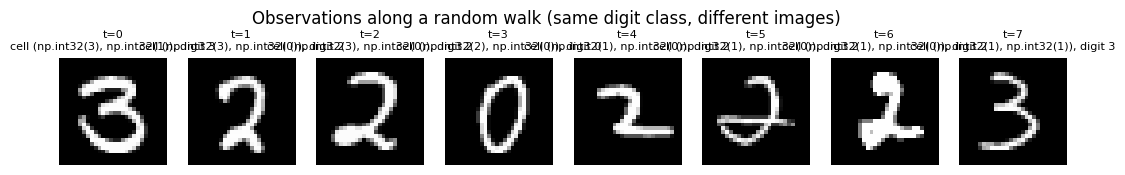

In [2]:
from environments.mnist_gridworld import (
    MNISTGridWorld, load_mnist, example_grid_aliased, example_grid_unique,
)

x_tr, y_tr, _, _ = load_mnist()
grid = example_grid_aliased()
env = MNISTGridWorld(grid, x_tr, y_tr, seed=0)
images, actions, positions, digits = env.rollout(steps=240)

print("digit grid (each cell value = an observation class):")
print(grid)
print(f"\nrollout: {images.shape[0]} steps, image shape {images.shape[1:]}")

# Observations along the trajectory: same digit class, different MNIST images.
fig, axes = plt.subplots(1, 8, figsize=(13, 2.1))
for k, ax in enumerate(axes):
    ax.imshow(images[k].squeeze(), cmap="gray")
    ax.set_title(f"t={k}\ncell {tuple(positions[k])}, digit {digits[k]}", fontsize=8)
    ax.axis("off")
fig.suptitle("Observations along a random walk (same digit class, different images)")
plt.show()

## 3. The method

**Two modules, one objective.**

**(a) VQ-VAE — the perceptual front-end ("the eye").** A convolutional encoder
maps each image to a latent vector, which is snapped to the nearest of *K*
codebook entries — producing one **discrete token** per image. The codebook is
updated by an exponential moving average; a straight-through estimator lets
gradients bypass the discrete step.

**(b) Cloned HMM / CSCG — the sequence model.** An action-conditioned cloned
hidden Markov model. Each token owns several **clone** states that share an
emission but differ in transition context; clones disambiguate perceptual
aliasing. The forward algorithm is implemented as a differentiable log-space
computation, so the model is trained by **backpropagation** rather than EM.

**The coupling.** In joint training the encoder emits a *soft posterior* over
the codebook and the HMM consumes it, making the whole pipeline differentiable
end-to-end — the topological objective shapes perception. Loss-balancing terms
(length normalization, weight annealing, a codebook-diversity penalty) keep
joint training stable.

See `paper/neuralCSCG_preprint.pdf` (Materials and Methods) for the full formal
treatment.

## 4. Quick demo — train the pipeline end-to-end

As a fast, self-contained check we train a **small** model from scratch on the
aliased 4×4 grid. This exercises the whole pipeline — VQ-VAE warmup,
tokenization, gradient-HMM training and Viterbi decoding — end-to-end in a few
minutes on CPU.

This is a deliberately brief run: the gradient-trained HMM needs the longer
training of Section 5 to fully converge, so it is used here only to confirm the
pipeline executes correctly. **Fully-converged, quantitative map-recovery
results are in Section 5** (five environments) **and Section 6** (a live run on
a fully-trained model).

For speed the demo enables two benchmark aids — dead-code revival and a light
digit-supervision signal on the VQ-VAE warmup; both are optional in the full
pipeline.

In [3]:
from models.vqvae_cscg import VQVAEGradientHMM

# A few short episodes on the aliased 4x4 grid.
demo_env = MNISTGridWorld(example_grid_aliased(), x_tr, y_tr, seed=1)
img_eps, act_eps, pos_eps, dig_eps = [], [], [], []
for _ in range(3):
    im, ac, po, di = demo_env.rollout(steps=500)
    img_eps.append(im); act_eps.append(ac); pos_eps.append(po); dig_eps.append(di)
train_images = np.concatenate(img_eps, axis=0)
train_labels = np.concatenate(dig_eps, axis=0)
print(f"collected {train_images.shape[0]} images over {len(img_eps)} episodes")

demo = VQVAEGradientHMM(
    image_shape=demo_env.image_shape,
    codebook_size=8, embedding_dim=16, num_clones=6,
    num_actions=demo_env.num_actions,
    dead_code_threshold=1.0,   # revive unused codes -> no codebook collapse
    seed=0,
)
history = demo.fit(
    images=train_images,
    image_sequences=img_eps, action_sequences=act_eps,
    vqvae_epochs=18, hmm_iters=1500,
    vqvae_batch_size=128, hmm_batch_size=3, hmm_lr=1e-2,
    image_labels=train_labels, vqvae_supervision_weight=0.3,
    seed=0, verbose=1,
)
nll = history.hmm_loss_history
print(f"\nVQ-VAE perplexity : {history.perplexity:.2f}  "
      f"({history.used_tokens} active tokens)")
print(f"HMM NLL           : {nll[0]:.1f} -> {nll[-1]:.1f}  (decreased over training)")
print("The pipeline ran end-to-end: images -> VQ-VAE -> tokens -> gradient-HMM.")

collected 1500 images over 3 episodes
Phase 1 stage 1/2: training VQ-VAE


Epoch 1/18 - total_loss: 0.6426 - recon_loss: 0.2310 - vq_loss: 0.0002 - class_loss: 1.3713 - perplexity: 2.5459


Epoch 2/18 - total_loss: 0.6341 - recon_loss: 0.2285 - vq_loss: 0.0006 - class_loss: 1.3498 - perplexity: 1.4400


Epoch 3/18 - total_loss: 0.6133 - recon_loss: 0.2173 - vq_loss: 0.0007 - class_loss: 1.3177 - perplexity: 2.4227


Epoch 4/18 - total_loss: 0.5569 - recon_loss: 0.1720 - vq_loss: 0.0064 - class_loss: 1.2616 - perplexity: 2.0063


...

[hmm  1200/1500] loss=302.735474


[hmm  1275/1500] loss=301.933228


[hmm  1350/1500] loss=301.324463


[hmm  1425/1500] loss=300.888641


[hmm  1500/1500] loss=300.552704

VQ-VAE perplexity : 5.38  (7 active tokens)
HMM NLL           : 1079.4 -> 300.6  (decreased over training)
The pipeline ran end-to-end: images -> VQ-VAE -> tokens -> gradient-HMM.


The trained model encodes images to discrete tokens and decodes trajectories
into clone-state sequences with Viterbi. Below: VQ-VAE reconstructions and a
decode of one episode.

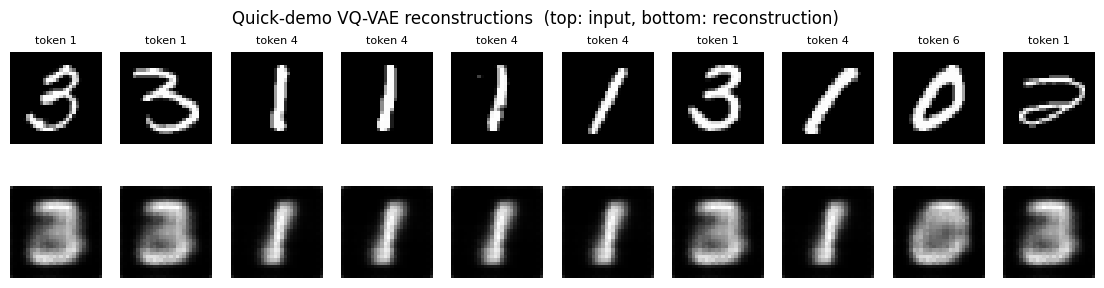

decoded a 500-step episode into a clone-state sequence (41 distinct states used)
Fully-converged, quantitative map-recovery results follow in Sections 5 and 6.


In [4]:
# VQ-VAE reconstructions: input (top) vs. reconstruction (bottom).
sample = train_images[:10]
recon = demo.reconstruct(sample)
tokens = demo.encode_images(sample)
fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for k in range(10):
    axes[0, k].imshow(sample[k].squeeze(), cmap="gray"); axes[0, k].axis("off")
    axes[0, k].set_title(f"token {int(tokens[k])}", fontsize=8)
    axes[1, k].imshow(np.clip(recon[k].squeeze(), 0, 1), cmap="gray")
    axes[1, k].axis("off")
fig.suptitle("Quick-demo VQ-VAE reconstructions  (top: input, bottom: reconstruction)")
plt.show()

# Decoding turns an episode into a clone-state sequence.
nll_d, states, toks = demo.decode_sequence(img_eps[0], act_eps[0])
print(f"decoded a {len(states)}-step episode into a clone-state sequence "
      f"({len(np.unique(states))} distinct states used)")
print("Fully-converged, quantitative map-recovery results follow in "
      "Sections 5 and 6.")

## 5. Reproducing the published runs

The five code cells below recreate each published run end-to-end. Each cell
uses the exact hyperparameters recorded in that run's `summary.txt` and
after training saves two diagnostic figures: a **clone-purity confusion
matrix** and the **Viterbi-path graph with MNIST-image nodes**.


### 5.1 `aliased` — 4×4 strongly-aliased grid

Codebook *K* = 4, clones per token = 5, **5,000** joint iterations and a **5,000-iteration** pure-HMM finalization phase.

collected 40000 images over 4 episodes
Phase 2 stage 1/2: VQ-VAE warmup (no HMM loss yet)
[joint] warming up VQ-VAE for 4 epoch(s)
Epoch 4/4 - total_loss: 0.0561 - recon_loss: 0.0541 - vq_loss: 0.0011 - class_loss: 0.32 - perplexity: 4.00
Phase 2 stage 2/3: joint training (lambda=1.0, anneal=1250, tau=1.0, beta=1.0, diversity=0.1, normalize=True, hmm_lr_mult=100.0)
[joint] (re)building HMM with num_states=21 (clone_counts sum over K=4 + sink)
[joint     1/5000] [training progress, 5000 iterations elided ...]
[joint  5000/5000] total=0.0725 recon=0.0529 commit=0.0086 hmm=2.7538 hmm_term=0.0108 div=0.0027 lambda=1.0000
Phase 2.5+ stage 3/3: pure-HMM finalization (5000 iters, encoder frozen, hard tokens, lr=0.01)
[finalize     1/5000] hmm_nll/seq=164.7000 hmm_nll/step=0.3216 lr=1.00e-02
[finalize  5000/5000] hmm_nll/seq=53.9000 hmm_nll/step=0.1193 lr=1.00e-02

VQ-VAE perplexity : 4.00  (4 active tokens)
joint HMM NLL     : 780.0 -> 2.8
finalize HMM NLL  : 164.7 -> 53.9


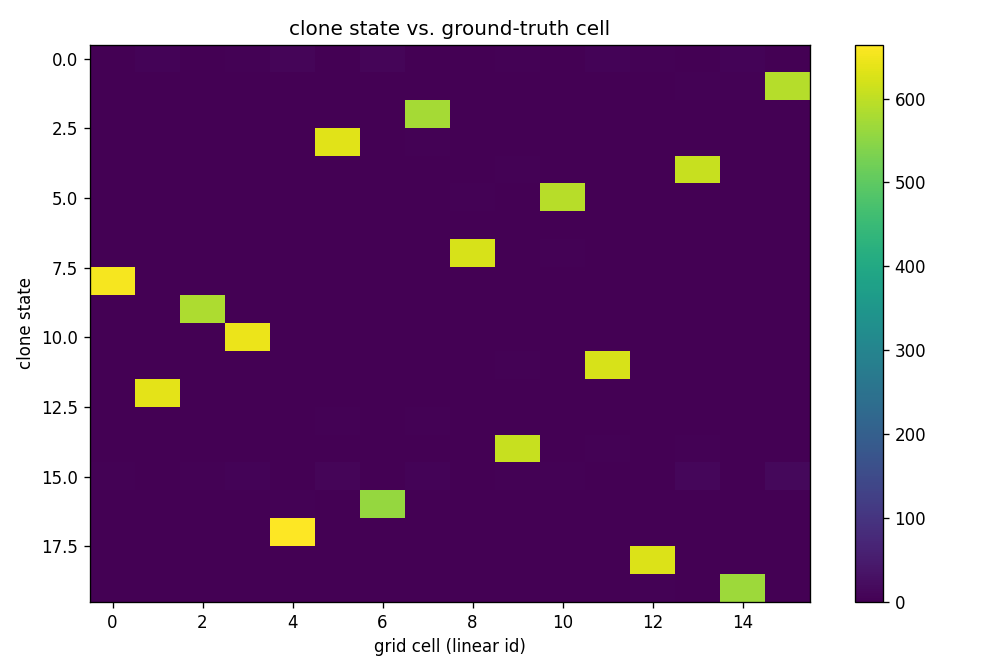

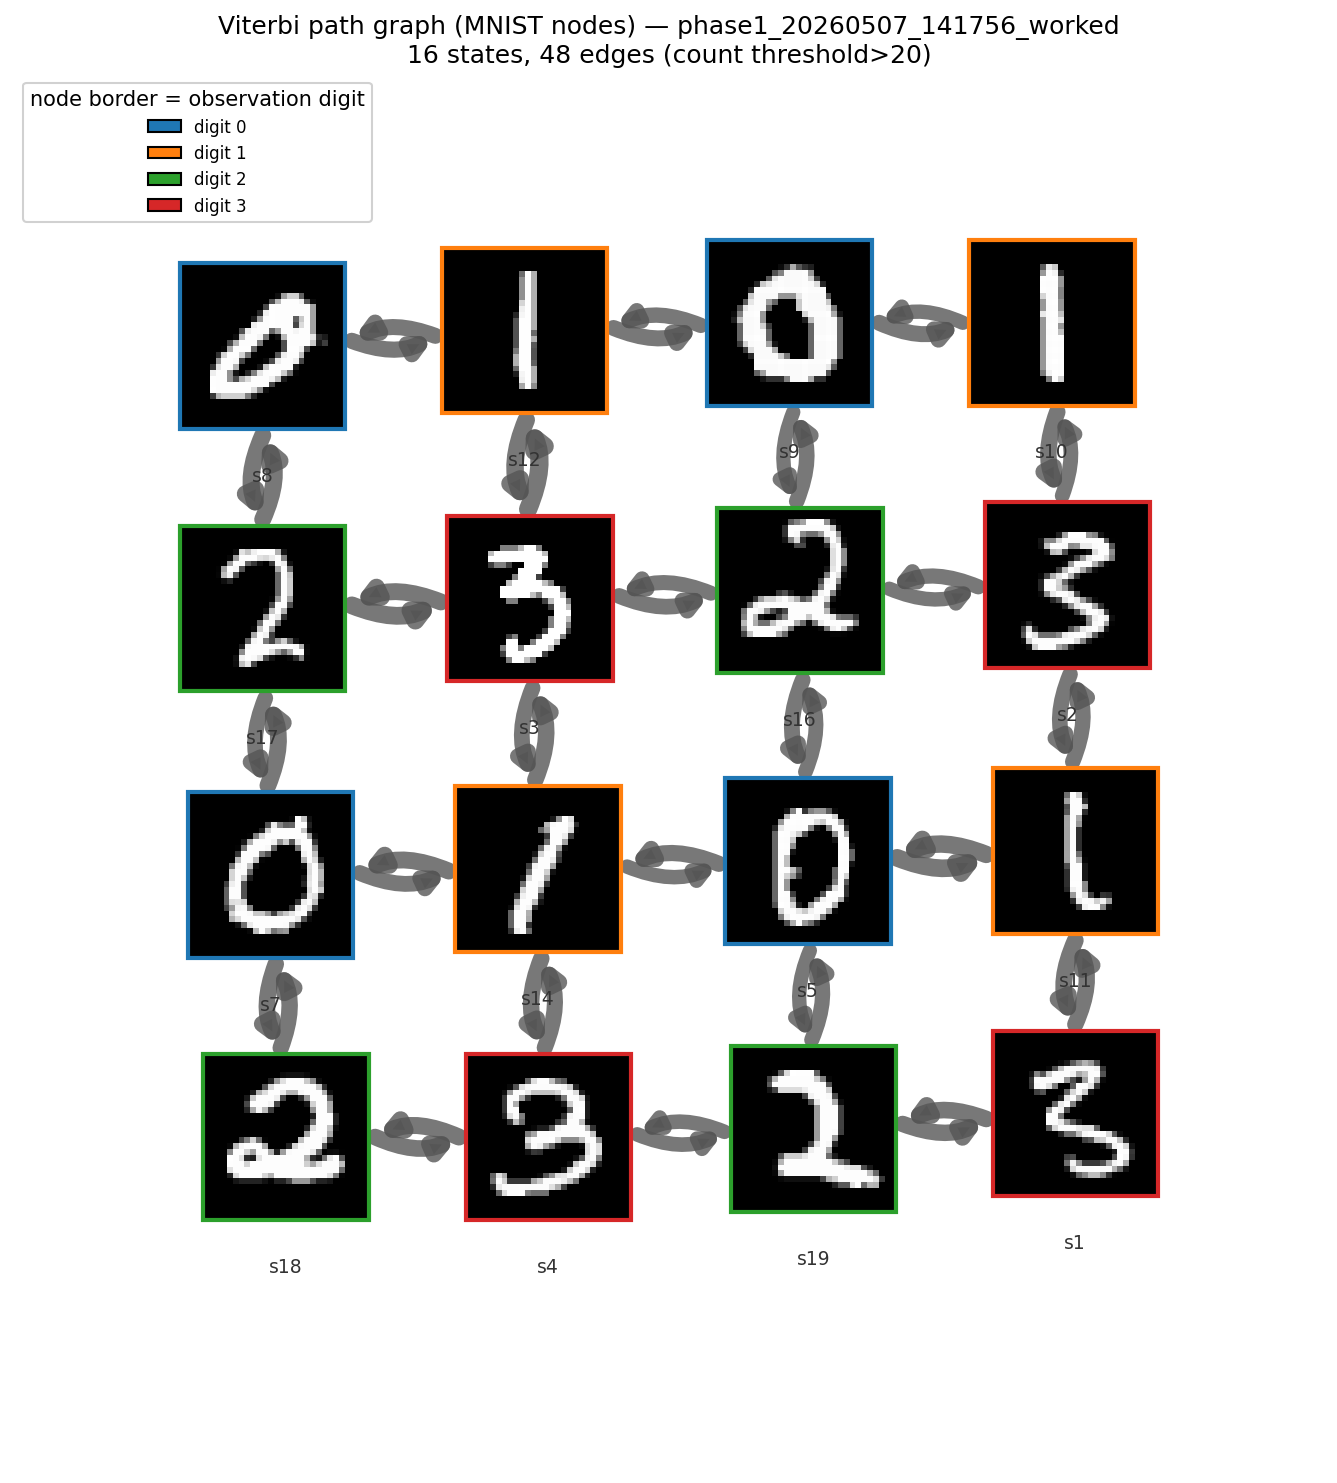

In [9]:
# WARNING: trains end-to-end -- about an hour on CPU. Not executed by default.
# Reproduces the `aliased` run.
import os
from models.vqvae_cscg import VQVAEGradientHMM
from environments.mnist_gridworld import example_grid_aliased
from examples.visualization import plot_clone_purity, render_viterbi_graph

# 1. Roll out episodes on the environment.
env = MNISTGridWorld(example_grid_aliased(), x_tr, y_tr, seed=0)
img_eps, act_eps, pos_eps, dig_eps = [], [], [], []
for _ in range(4):
    im, ac, po, di = env.rollout(steps=10000)
    img_eps.append(im); act_eps.append(ac); pos_eps.append(po); dig_eps.append(di)
train_images = np.concatenate(img_eps, axis=0)
train_labels = np.concatenate(dig_eps, axis=0)
print(f"collected {train_images.shape[0]} images over {len(img_eps)} episodes")

# 2. Build the VQ-VAE + cloned-HMM with the published hyperparameters.
model = VQVAEGradientHMM(
    image_shape=env.image_shape,
    codebook_size=4, num_clones=5,
    num_actions=env.num_actions, seed=0,
)

# 3. Phase 2 joint training + pure-HMM finalization.
history = model.fit_joint_pipeline(
    images=train_images,
    image_sequences=img_eps, action_sequences=act_eps,
    image_labels=train_labels, vqvae_supervision_weight=0.1,
    joint_iters=5000,
    hmm_lr_multiplier=100,
    finalize_hmm_iters=5000,
    seed=0, verbose=1,
)
nll = history.hmm_loss_history
print(f"\nVQ-VAE perplexity : {history.perplexity:.2f}  "
      f"({history.used_tokens} active tokens)")
print(f"joint HMM NLL     : {nll[0]:.1f} -> {nll[-1]:.1f}")
if history.finalize_history:
    print(f"finalize HMM NLL  : {history.finalize_history[0]:.1f} -> "
          f"{history.finalize_history[-1]:.1f}")

# 4. Visualizations: clone purity + Viterbi-path graph (MNIST-image nodes).
out = "_repro_aliased"
os.makedirs(out, exist_ok=True)
plot_clone_purity(model, img_eps[0], act_eps[0], pos_eps[0],
                  f"{out}/clone_purity.png")
render_viterbi_graph(model, img_eps[0], act_eps[0], dig_eps[0],
                     f"{out}/viterbi_graph.png", count_threshold=20,
                     title="Viterbi path graph (MNIST nodes) - aliased")
show_image(f"{out}/clone_purity.png", width=560)
show_image(f"{out}/viterbi_graph.png", width=560)

### 5.2 `corridors` — 5×5 walled grid with corridor aliasing

Codebook *K* = 6, clones per token = 5, **2,000** joint iterations, encoder frozen during joint, **1,000-iteration** finalization with a transition-entropy penalty.

collected 40000 images over 4 episodes
Phase 2 stage 1/2: VQ-VAE warmup (no HMM loss yet)
[joint] warming up VQ-VAE for 4 epoch(s)
Epoch 4/4 - total_loss: 0.0531 - recon_loss: 0.0511 - vq_loss: 0.0011 - class_loss: 0.32 - perplexity: 5.71
Phase 2 stage 2/3: joint training (lambda=1.0, anneal=500, tau=1.0, beta=1.0, diversity=0.1, normalize=True, hmm_lr_mult=100.0)
[joint] (re)building HMM with num_states=31 (clone_counts sum over K=6 + sink)
[joint     1/2000] [training progress, 2000 iterations elided ...]
[joint  2000/2000] total=0.1689 recon=0.0528 commit=0.0056 hmm=25.9952 hmm_term=0.1015 div=0.0886 lambda=1.0000
Phase 2.5+ stage 3/3: pure-HMM finalization (1000 iters, encoder frozen, hard tokens, lr=0.01)
[finalize     1/1000] hmm_nll/seq=6667.4000 hmm_nll/step=0.6667 lr=1.00e-02
[finalize  1000/1000] hmm_nll/seq=1566.7000 hmm_nll/step=0.1567 lr=1.00e-02

VQ-VAE perplexity : 5.71  (6 active tokens)
joint HMM NLL     : 880.0 -> 26.0
finalize HMM NLL  : 6667.4 -> 1566.7


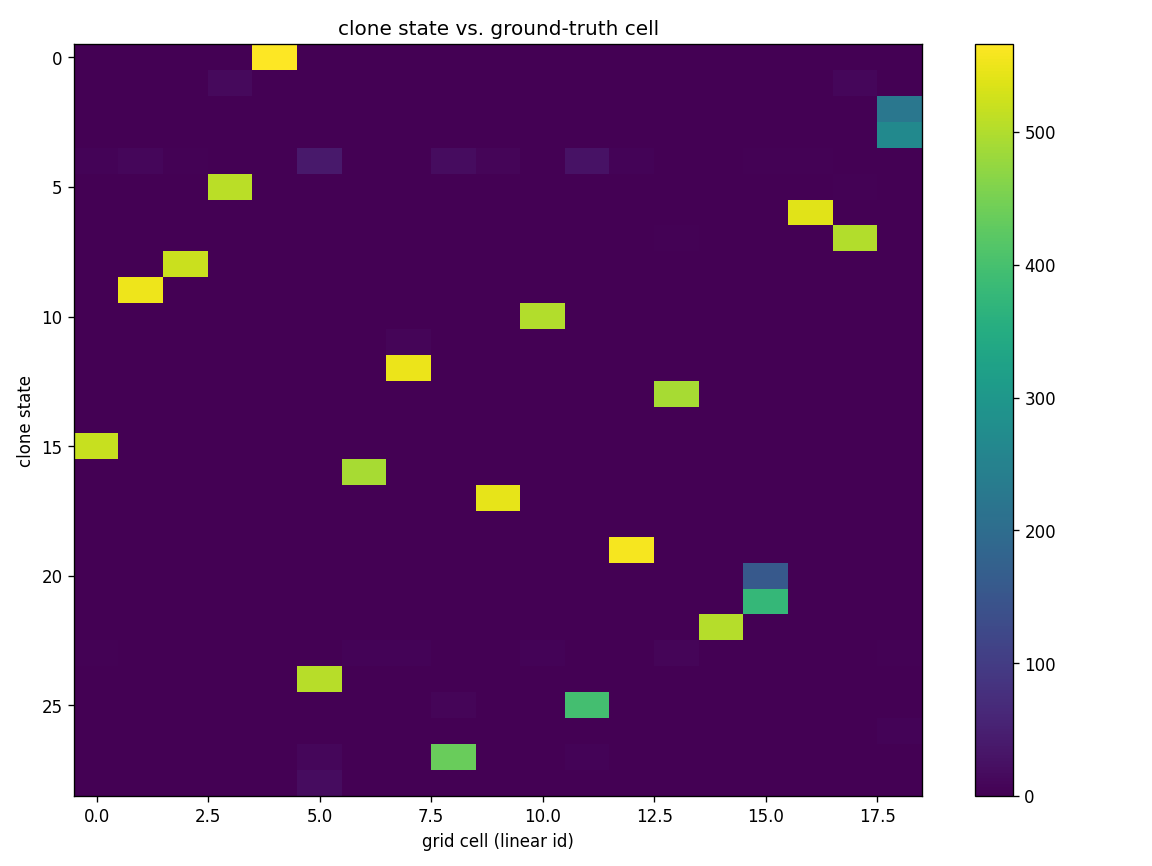

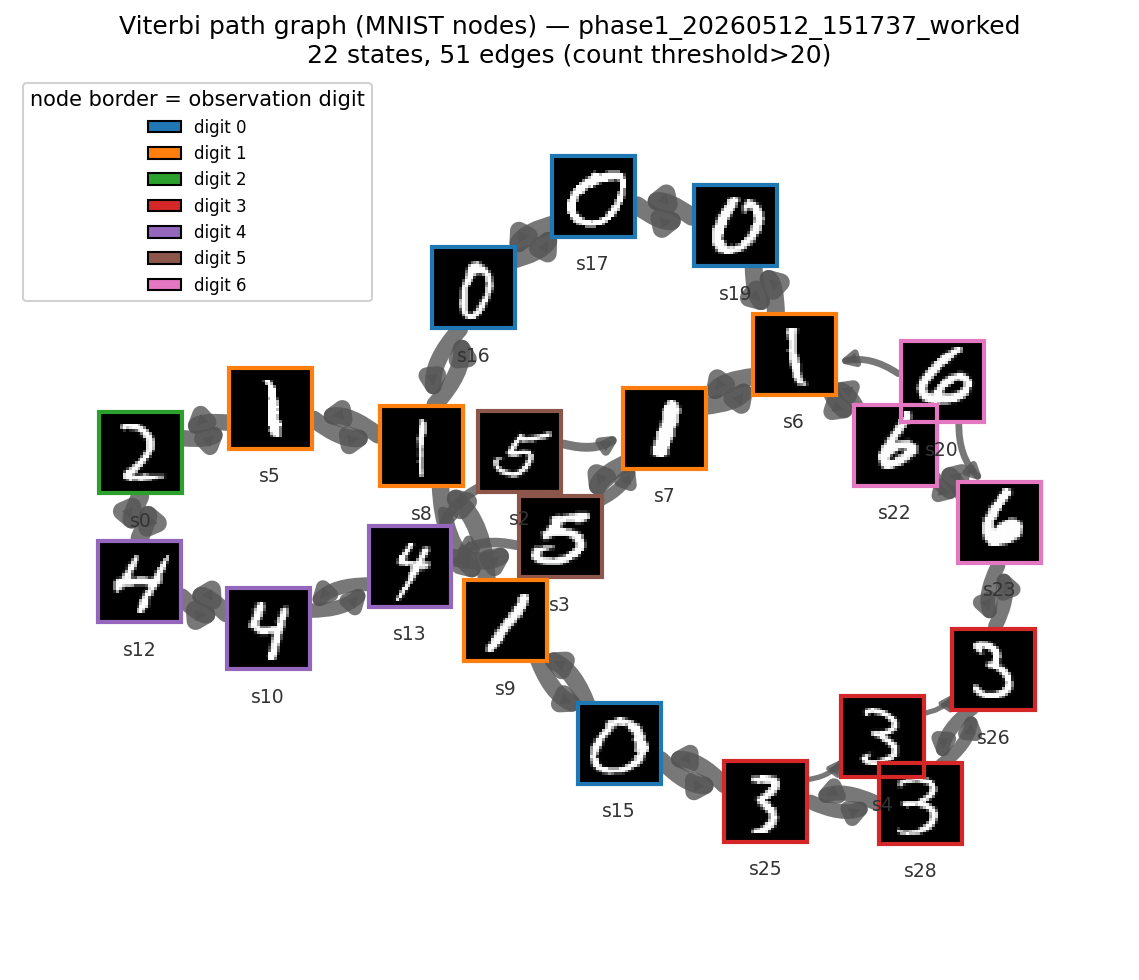

In [10]:
# WARNING: trains end-to-end -- about an hour on CPU. Not executed by default.
# Reproduces the `corridors` run.
import os
from models.vqvae_cscg import VQVAEGradientHMM
from environments.mnist_gridworld import example_grid_corridors
from examples.visualization import plot_clone_purity, render_viterbi_graph

# 1. Roll out episodes on the environment.
env = MNISTGridWorld(example_grid_corridors(), x_tr, y_tr, seed=0)
img_eps, act_eps, pos_eps, dig_eps = [], [], [], []
for _ in range(4):
    im, ac, po, di = env.rollout(steps=10000)
    img_eps.append(im); act_eps.append(ac); pos_eps.append(po); dig_eps.append(di)
train_images = np.concatenate(img_eps, axis=0)
train_labels = np.concatenate(dig_eps, axis=0)
print(f"collected {train_images.shape[0]} images over {len(img_eps)} episodes")

# 2. Build the VQ-VAE + cloned-HMM with the published hyperparameters.
model = VQVAEGradientHMM(
    image_shape=env.image_shape,
    codebook_size=6, num_clones=5,
    num_actions=env.num_actions, seed=0,
)

# 3. Phase 2 joint training + pure-HMM finalization.
history = model.fit_joint_pipeline(
    images=train_images,
    image_sequences=img_eps, action_sequences=act_eps,
    image_labels=train_labels, vqvae_supervision_weight=0.1,
    joint_iters=2000,
    hmm_lr_multiplier=100,
    freeze_vqvae_during_joint=True,
    finalize_hmm_iters=1000,
    finalize_hmm_transition_entropy=0.001,
    seed=0, verbose=1,
)
nll = history.hmm_loss_history
print(f"\nVQ-VAE perplexity : {history.perplexity:.2f}  "
      f"({history.used_tokens} active tokens)")
print(f"joint HMM NLL     : {nll[0]:.1f} -> {nll[-1]:.1f}")
if history.finalize_history:
    print(f"finalize HMM NLL  : {history.finalize_history[0]:.1f} -> "
          f"{history.finalize_history[-1]:.1f}")

# 4. Visualizations: clone purity + Viterbi-path graph (MNIST-image nodes).
out = "_repro_corridors"
os.makedirs(out, exist_ok=True)
plot_clone_purity(model, img_eps[0], act_eps[0], pos_eps[0],
                  f"{out}/clone_purity.png")
render_viterbi_graph(model, img_eps[0], act_eps[0], dig_eps[0],
                     f"{out}/viterbi_graph.png", count_threshold=20,
                     title="Viterbi path graph (MNIST nodes) - corridors")
show_image(f"{out}/clone_purity.png", width=560)
show_image(f"{out}/viterbi_graph.png", width=560)

### 5.3 `room_uniform` — 6×6 room, uniform clone allocation

Codebook *K* = 10, **uniform 20 clones per token** (201 latent states), **2,000** joint iterations and a **1,250-iteration** finalization.

collected 40000 images over 4 episodes
Phase 2 stage 1/2: VQ-VAE warmup (no HMM loss yet)
[joint] warming up VQ-VAE for 4 epoch(s)
Epoch 4/4 - total_loss: 0.0590 - recon_loss: 0.0570 - vq_loss: 0.0011 - class_loss: 0.32 - perplexity: 6.63
Phase 2 stage 2/3: joint training (lambda=1.0, anneal=500, tau=1.0, beta=1.0, diversity=0.1, normalize=True, hmm_lr_mult=100.0)
[joint] (re)building HMM with num_states=201 (clone_counts sum over K=10 + sink)
[joint     1/2000] [training progress, 2000 iterations elided ...]
[joint  2000/2000] total=0.3082 recon=0.0566 commit=0.0076 hmm=52.7107 hmm_term=0.2059 div=0.3810 lambda=1.0000
Phase 2.5+ stage 3/3: pure-HMM finalization (1250 iters, encoder frozen, hard tokens, lr=0.01)
[finalize     1/1250] hmm_nll/seq=10087.7000 hmm_nll/step=1.0088 lr=1.00e-02
[finalize  1250/1250] hmm_nll/seq=2367.0000 hmm_nll/step=0.2367 lr=1.00e-02

VQ-VAE perplexity : 6.63  (10 active tokens)
joint HMM NLL     : 1360.0 -> 52.7
finalize HMM NLL  : 10087.7 -> 2367.0


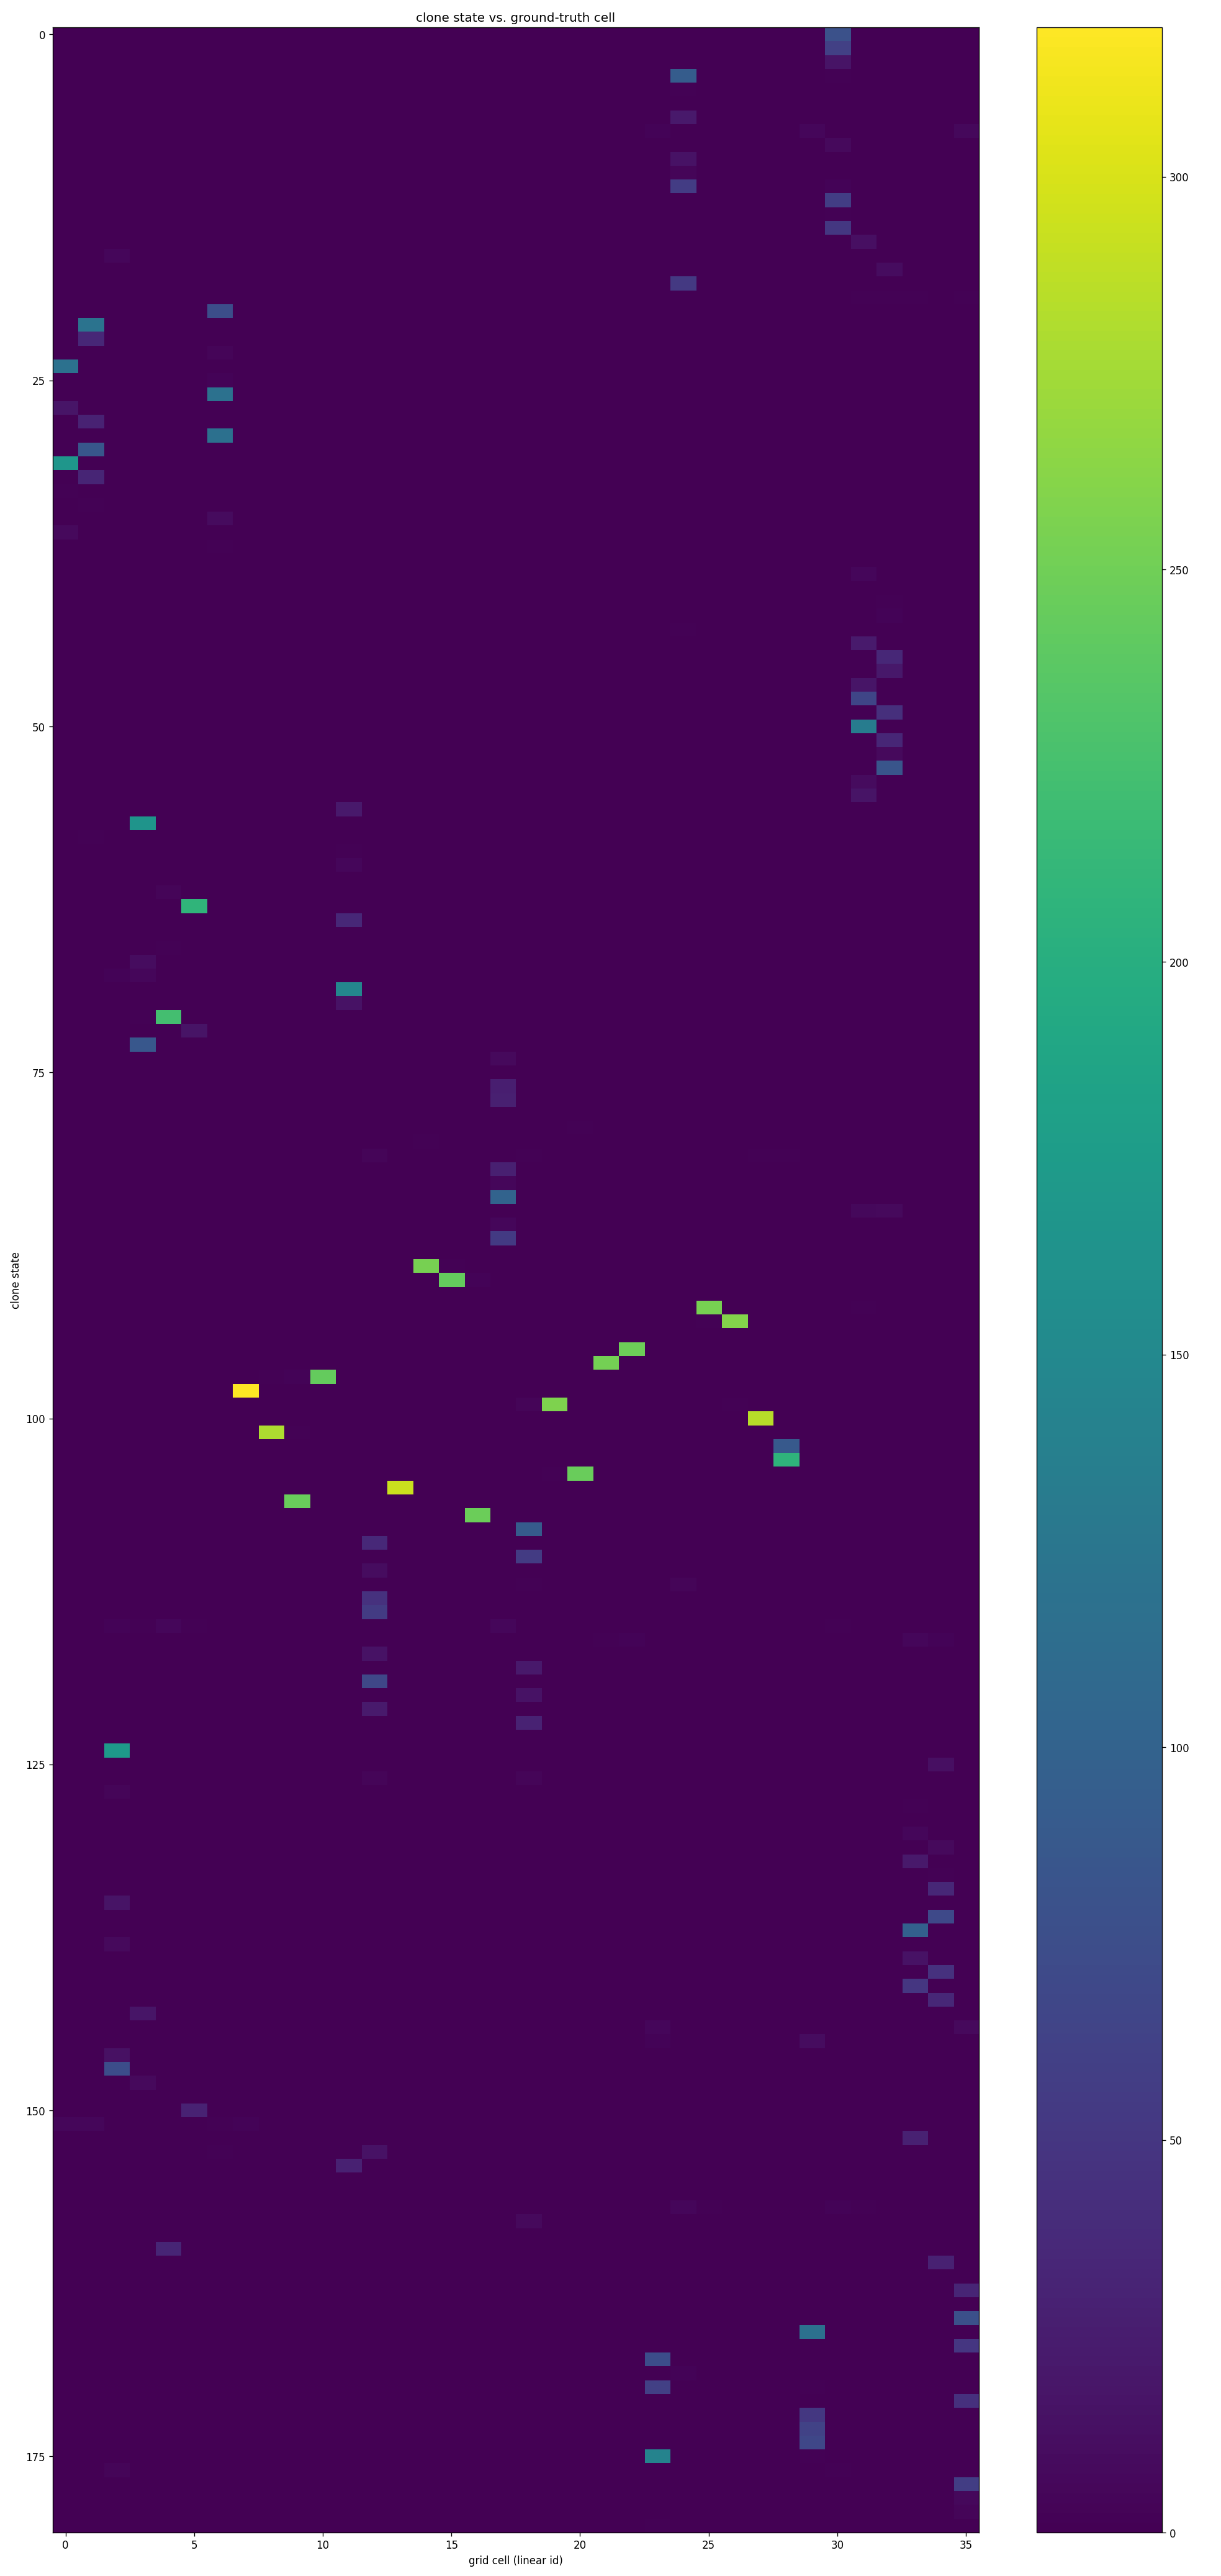

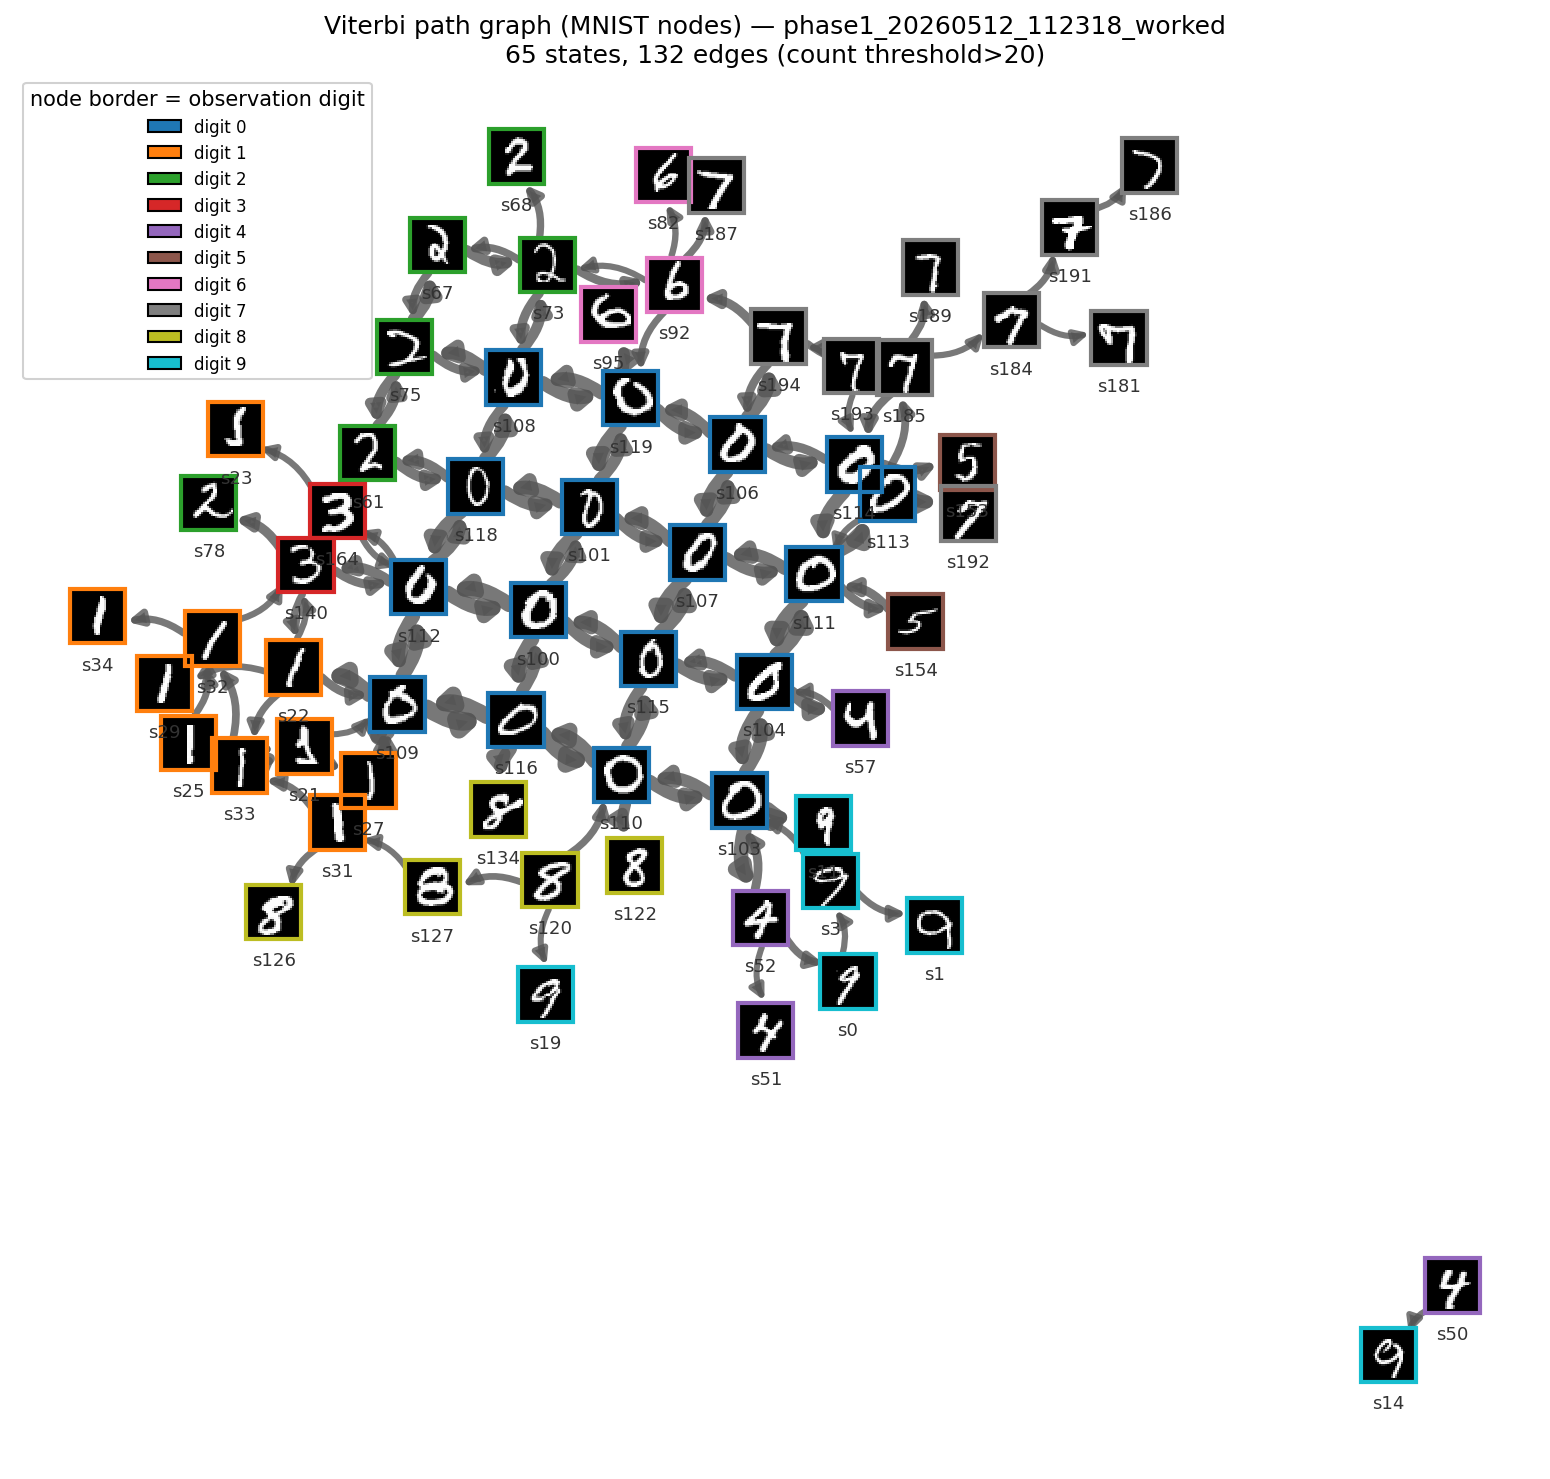

In [11]:
# WARNING: trains end-to-end -- about an hour on CPU. Not executed by default.
# Reproduces the `room_uniform` run.
import os
from models.vqvae_cscg import VQVAEGradientHMM
from environments.mnist_gridworld import example_grid_empty_notebook_room
from examples.visualization import plot_clone_purity, render_viterbi_graph

# 1. Roll out episodes on the environment.
env = MNISTGridWorld(example_grid_empty_notebook_room(), x_tr, y_tr, seed=0)
img_eps, act_eps, pos_eps, dig_eps = [], [], [], []
for _ in range(4):
    im, ac, po, di = env.rollout(steps=10000)
    img_eps.append(im); act_eps.append(ac); pos_eps.append(po); dig_eps.append(di)
train_images = np.concatenate(img_eps, axis=0)
train_labels = np.concatenate(dig_eps, axis=0)
print(f"collected {train_images.shape[0]} images over {len(img_eps)} episodes")

# 2. Build the VQ-VAE + cloned-HMM with the published hyperparameters.
model = VQVAEGradientHMM(
    image_shape=env.image_shape,
    codebook_size=10, num_clones=20,
    num_actions=env.num_actions, seed=0,
)

# 3. Phase 2 joint training + pure-HMM finalization.
history = model.fit_joint_pipeline(
    images=train_images,
    image_sequences=img_eps, action_sequences=act_eps,
    image_labels=train_labels, vqvae_supervision_weight=0.1,
    joint_iters=2000,
    hmm_lr_multiplier=100,
    freeze_vqvae_during_joint=True,
    finalize_hmm_iters=1250,
    finalize_hmm_transition_entropy=0.001,
    seed=0, verbose=1,
)
nll = history.hmm_loss_history
print(f"\nVQ-VAE perplexity : {history.perplexity:.2f}  "
      f"({history.used_tokens} active tokens)")
print(f"joint HMM NLL     : {nll[0]:.1f} -> {nll[-1]:.1f}")
if history.finalize_history:
    print(f"finalize HMM NLL  : {history.finalize_history[0]:.1f} -> "
          f"{history.finalize_history[-1]:.1f}")

# 4. Visualizations: clone purity + Viterbi-path graph (MNIST-image nodes).
out = "_repro_room_uniform"
os.makedirs(out, exist_ok=True)
plot_clone_purity(model, img_eps[0], act_eps[0], pos_eps[0],
                  f"{out}/clone_purity.png")
render_viterbi_graph(model, img_eps[0], act_eps[0], dig_eps[0],
                     f"{out}/viterbi_graph.png", count_threshold=20,
                     title="Viterbi path graph (MNIST nodes) - room_uniform")
show_image(f"{out}/clone_purity.png", width=560)
show_image(f"{out}/viterbi_graph.png", width=560)

### 5.4 `room_dynamic` — 6×6 room, dynamic clone allocation

Same environment as `room_uniform`, but clone counts are allocated **per digit class**: 20 clones for digit 0, 4 for each other digit (57 latent states).

collected 40000 images over 4 episodes
Phase 2 stage 1/2: VQ-VAE warmup (no HMM loss yet)
[joint] warming up VQ-VAE for 4 epoch(s)
Epoch 4/4 - total_loss: 0.0591 - recon_loss: 0.0571 - vq_loss: 0.0011 - class_loss: 0.32 - perplexity: 6.56
[clone-counts] resolved observation-label counts to VQ tokens: {0: {'label': 6, 'clones': 4}, 1: {'label': 1, 'clones': 4}, 2: {'label': 2, 'clones': 4}, 3: {'label': 4, 'clones': 4}, 4: {'label': 3, 'clones': 4}, 5: {'label': 5, 'clones': 4}, 6: {'label': 8, 'clones': 4}, 7: {'label': 0, 'clones': 20}, 8: {'label': 9, 'clones': 4}, 9: {'label': 7, 'clones': 4}}
Phase 2 stage 2/3: joint training (lambda=1.0, anneal=500, tau=1.0, beta=1.0, diversity=0.1, normalize=True, hmm_lr_mult=100.0)
[joint] (re)building HMM with num_states=57 (clone_counts sum over K=10 + sink)
[joint     1/2000] [training progress, 2000 iterations elided ...]
[joint  2000/2000] total=0.2237 recon=0.0567 commit=0.0063 hmm=31.2911 hmm_term=0.1222 div=0.3857 lambda=1.0000
Phase 2.5

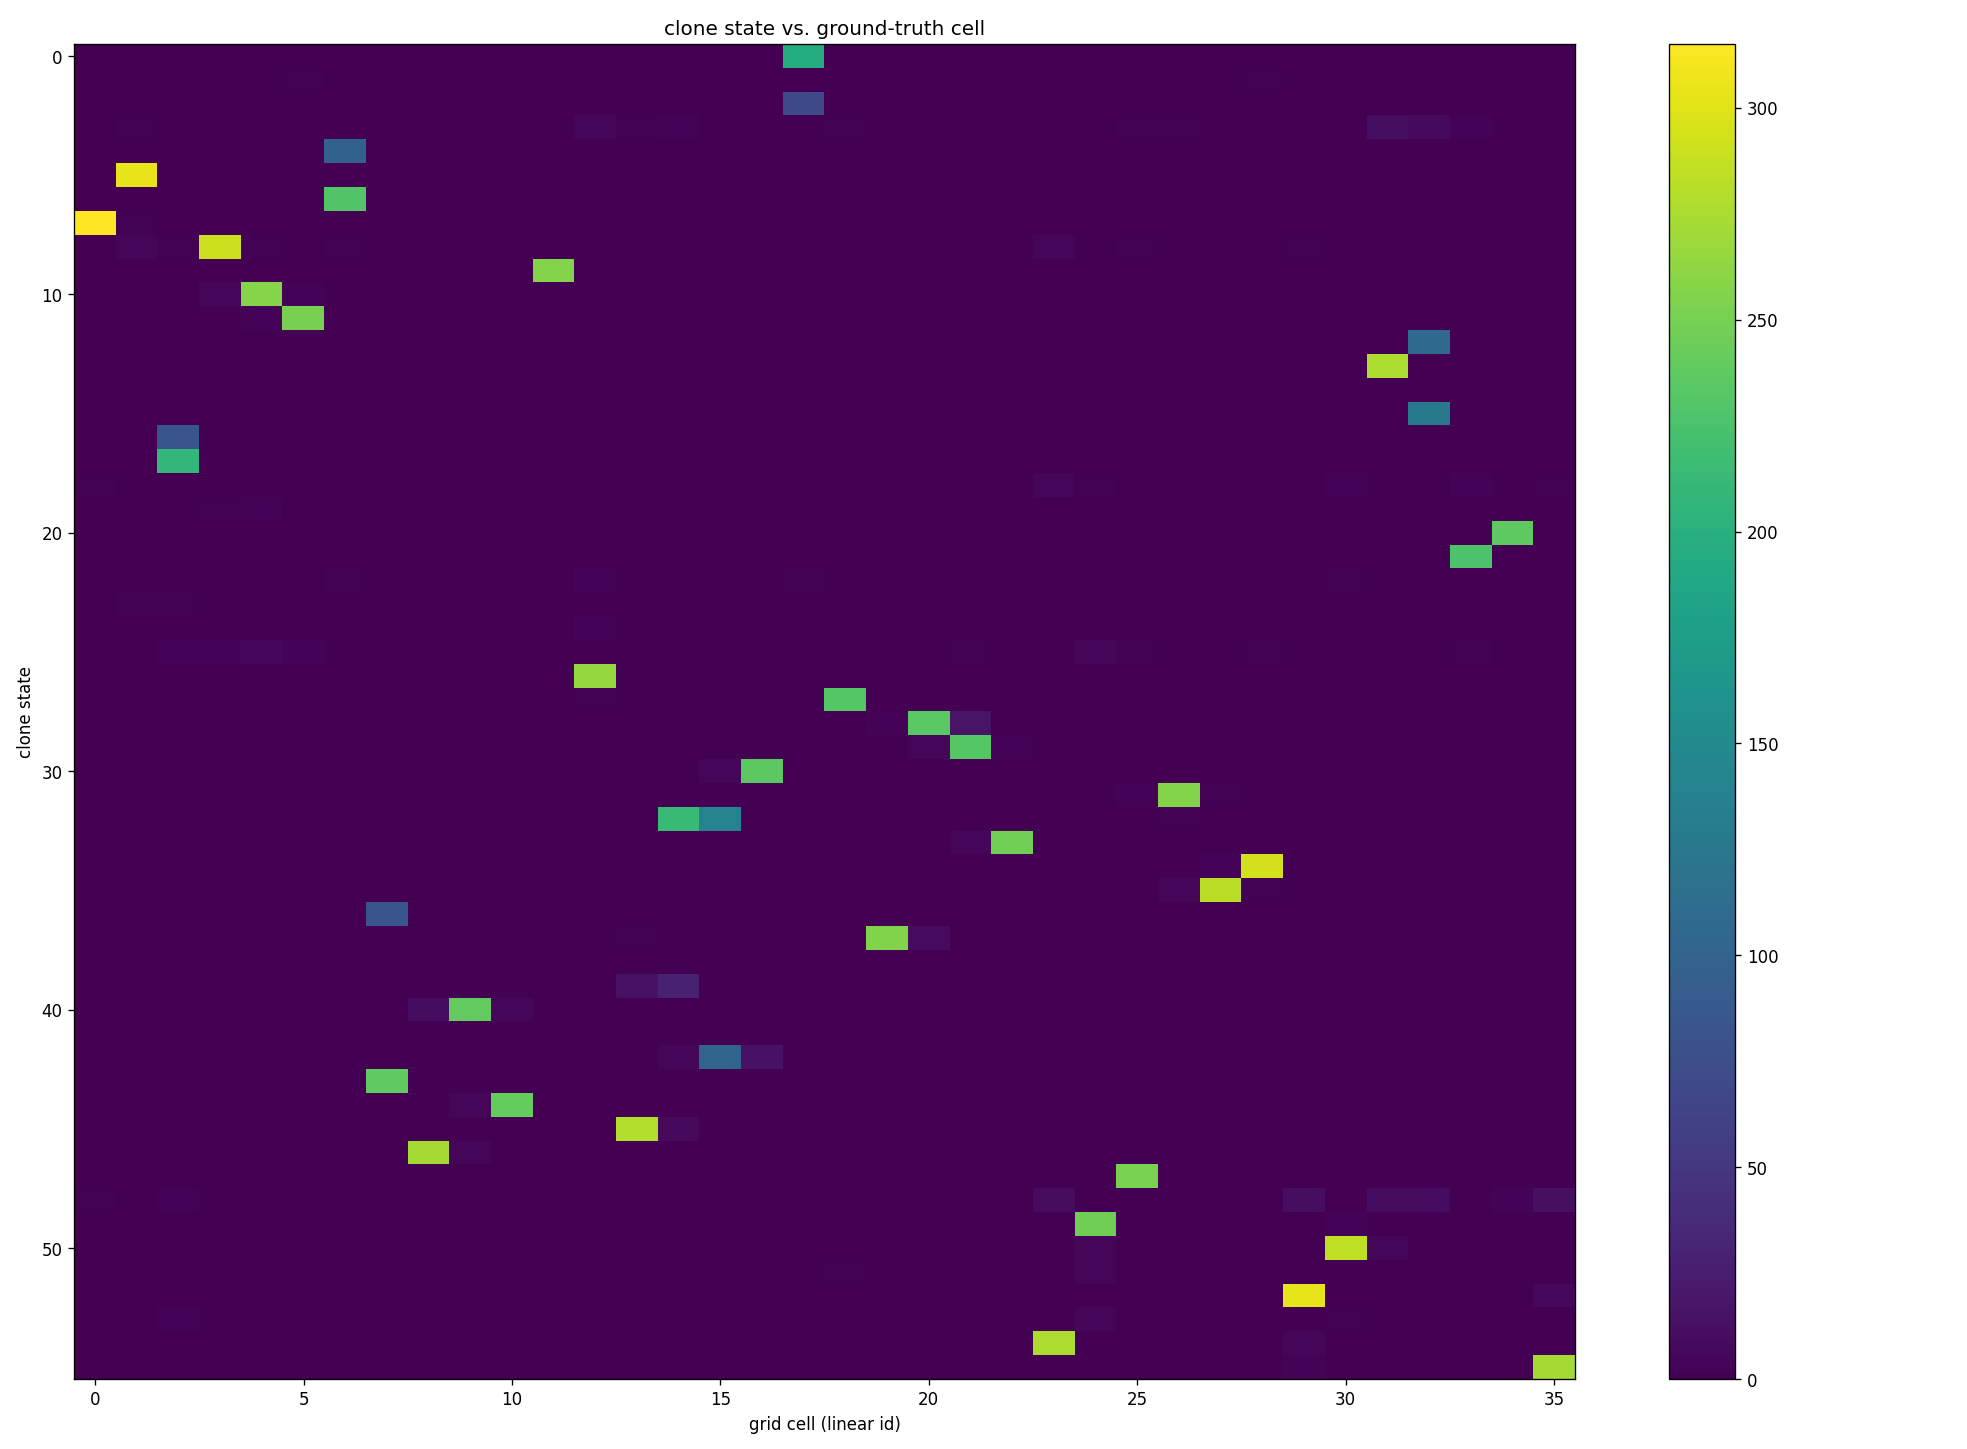

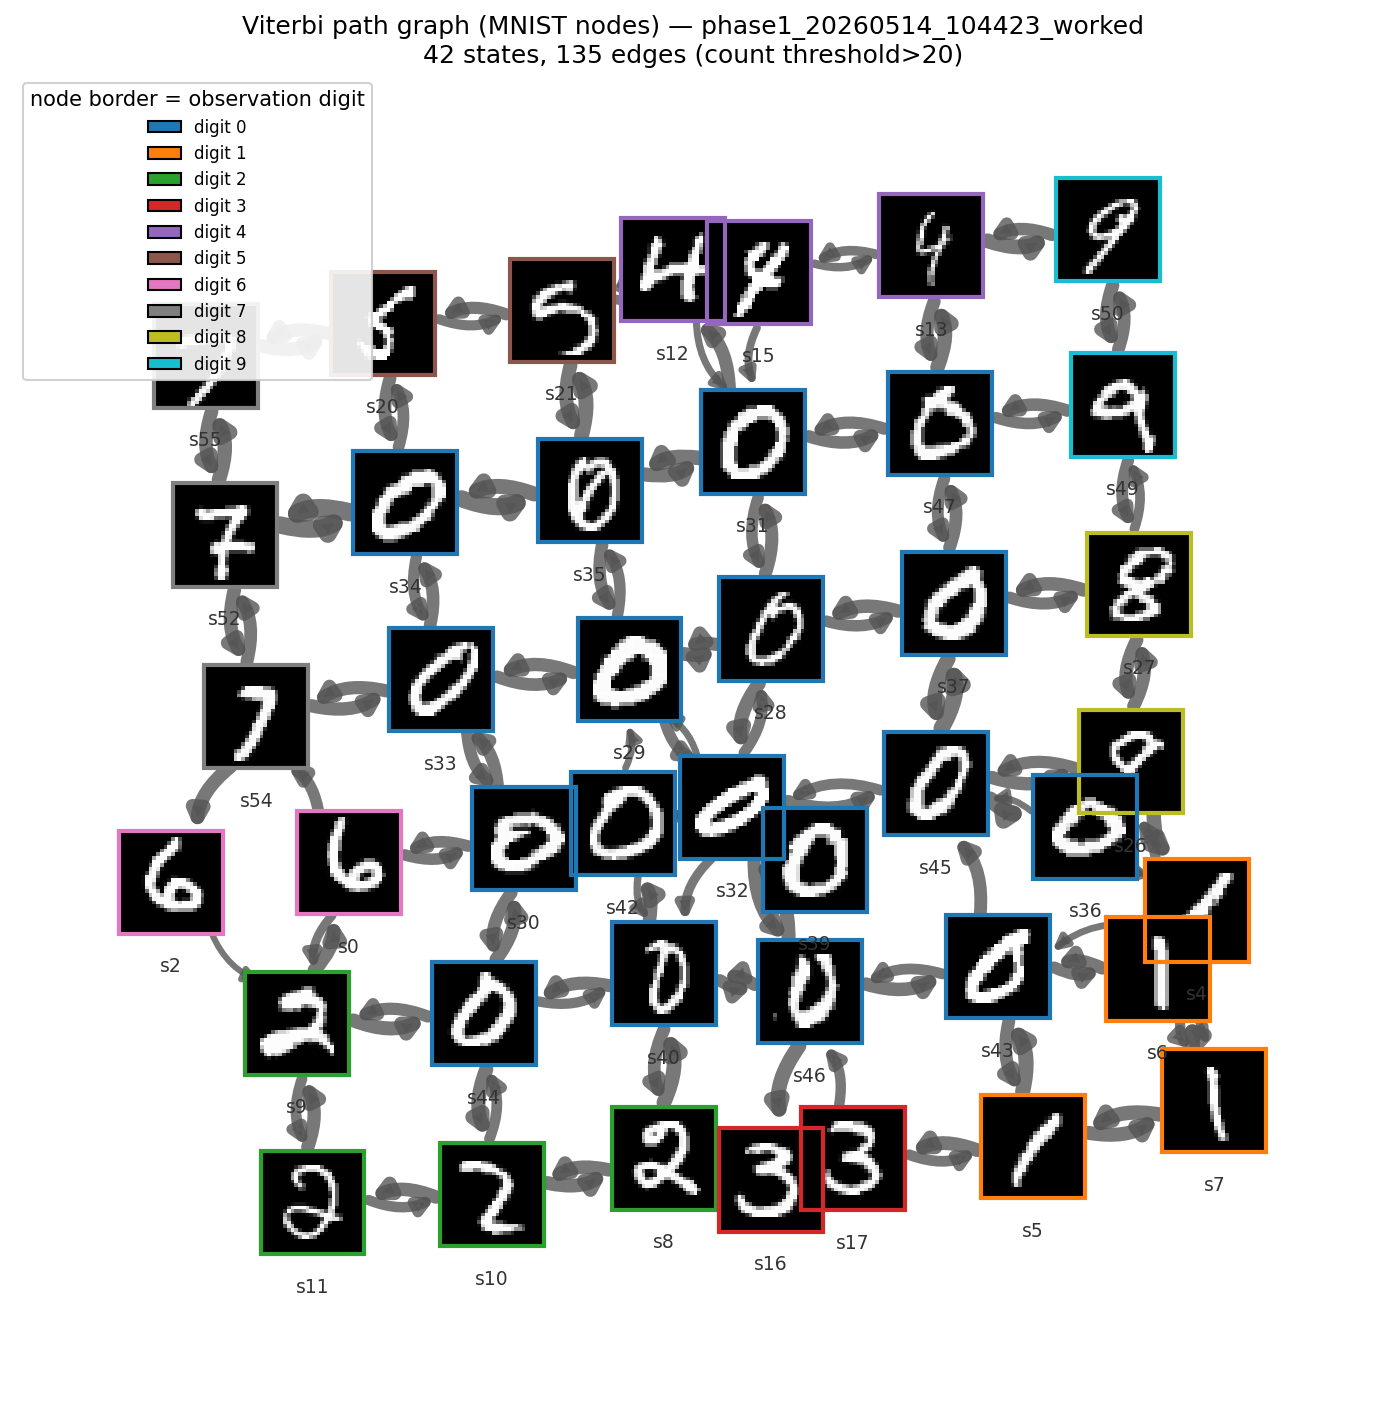

In [12]:
# WARNING: trains end-to-end -- about an hour on CPU. Not executed by default.
# Reproduces the `room_dynamic` run.
import os
from models.vqvae_cscg import VQVAEGradientHMM
from environments.mnist_gridworld import example_grid_empty_notebook_room
from examples.visualization import plot_clone_purity, render_viterbi_graph

# 1. Roll out episodes on the environment.
env = MNISTGridWorld(example_grid_empty_notebook_room(), x_tr, y_tr, seed=0)
img_eps, act_eps, pos_eps, dig_eps = [], [], [], []
for _ in range(4):
    im, ac, po, di = env.rollout(steps=10000)
    img_eps.append(im); act_eps.append(ac); pos_eps.append(po); dig_eps.append(di)
train_images = np.concatenate(img_eps, axis=0)
train_labels = np.concatenate(dig_eps, axis=0)
print(f"collected {train_images.shape[0]} images over {len(img_eps)} episodes")

# 2. Build the VQ-VAE + cloned-HMM with the published hyperparameters.
model = VQVAEGradientHMM(
    image_shape=env.image_shape,
    codebook_size=10, num_clones=20,
    num_actions=env.num_actions, seed=0,
)

# 3. Phase 2 joint training + pure-HMM finalization.
history = model.fit_joint_pipeline(
    images=train_images,
    image_sequences=img_eps, action_sequences=act_eps,
    image_labels=train_labels, vqvae_supervision_weight=0.1,
    observation_clone_counts=[20, 4, 4, 4, 4, 4, 4, 4, 4, 4],
    joint_iters=2000,
    hmm_lr_multiplier=100,
    freeze_vqvae_during_joint=True,
    finalize_hmm_iters=1000,
    finalize_hmm_transition_entropy=0.001,
    seed=0, verbose=1,
)
nll = history.hmm_loss_history
print(f"\nVQ-VAE perplexity : {history.perplexity:.2f}  "
      f"({history.used_tokens} active tokens)")
print(f"joint HMM NLL     : {nll[0]:.1f} -> {nll[-1]:.1f}")
if history.finalize_history:
    print(f"finalize HMM NLL  : {history.finalize_history[0]:.1f} -> "
          f"{history.finalize_history[-1]:.1f}")

# 4. Visualizations: clone purity + Viterbi-path graph (MNIST-image nodes).
out = "_repro_room_dynamic"
os.makedirs(out, exist_ok=True)
plot_clone_purity(model, img_eps[0], act_eps[0], pos_eps[0],
                  f"{out}/clone_purity.png")
render_viterbi_graph(model, img_eps[0], act_eps[0], dig_eps[0],
                     f"{out}/viterbi_graph.png", count_threshold=20,
                     title="Viterbi path graph (MNIST nodes) - room_dynamic")
show_image(f"{out}/clone_purity.png", width=560)
show_image(f"{out}/viterbi_graph.png", width=560)

### 5.5 `two_rooms` — 13×9 two interconnected rooms (showcase)

The hardest case: 10 episodes × 10,000 steps, codebook *K* = 10, **15 clones per digit** (151 latent states), **2,000** joint iterations and a **1,000-iteration** finalization.

collected 100000 images over 10 episodes
Phase 2 stage 1/2: VQ-VAE warmup (no HMM loss yet)
[joint] warming up VQ-VAE for 4 epoch(s)
Epoch 4/4 - total_loss: 0.0564 - recon_loss: 0.0544 - vq_loss: 0.0011 - class_loss: 0.32 - perplexity: 9.46
[clone-counts] resolved observation-label counts to VQ tokens: {0: {'label': 7, 'clones': 15}, 1: {'label': 0, 'clones': 15}, 2: {'label': 8, 'clones': 15}, 3: {'label': 4, 'clones': 15}, 4: {'label': 1, 'clones': 15}, 5: {'label': 9, 'clones': 15}, 6: {'label': 2, 'clones': 15}, 7: {'label': 6, 'clones': 15}, 8: {'label': 6, 'clones': 15}, 9: {'label': 3, 'clones': 15}}
Phase 2 stage 2/3: joint training (lambda=1.0, anneal=500, tau=1.0, beta=1.0, diversity=0.1, normalize=True, hmm_lr_mult=100.0)
[joint] (re)building HMM with num_states=151 (clone_counts sum over K=10 + sink)
[joint     1/2000] [training progress, 2000 iterations elided ...]
[joint  2000/2000] total=0.3435 recon=0.0545 commit=0.0060 hmm=70.6310 hmm_term=0.2759 div=0.0713 lambda=1.00

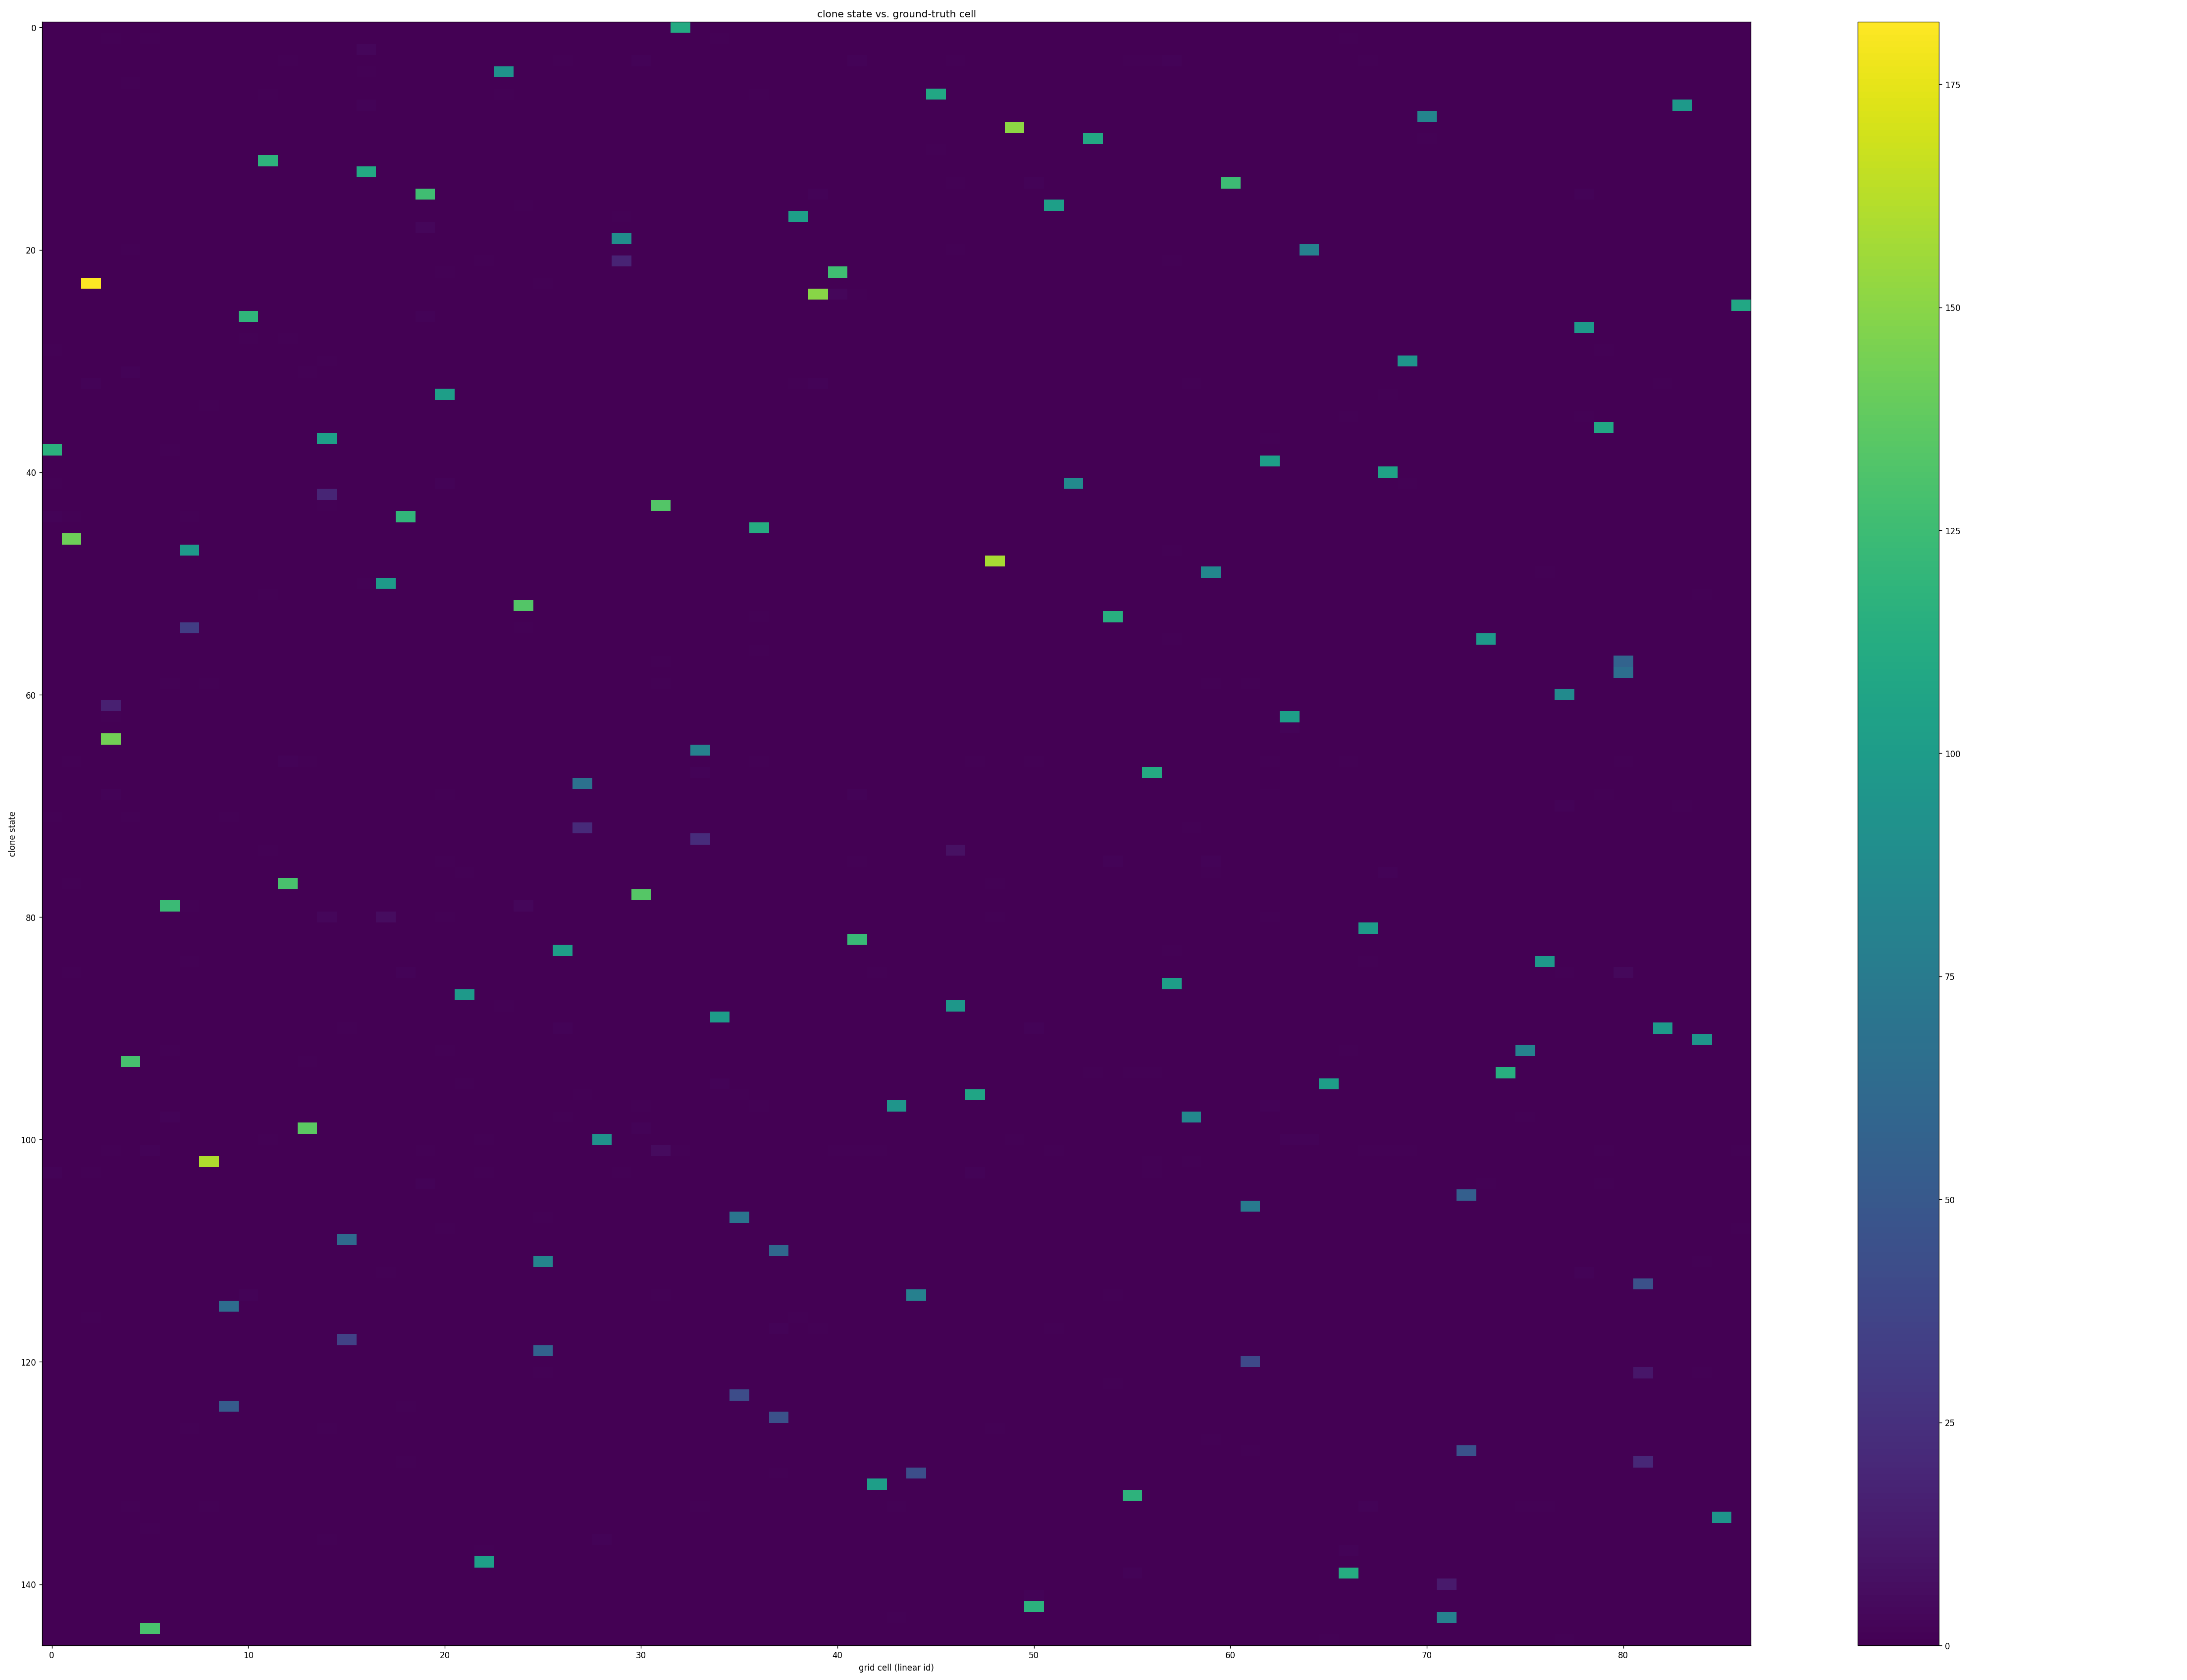

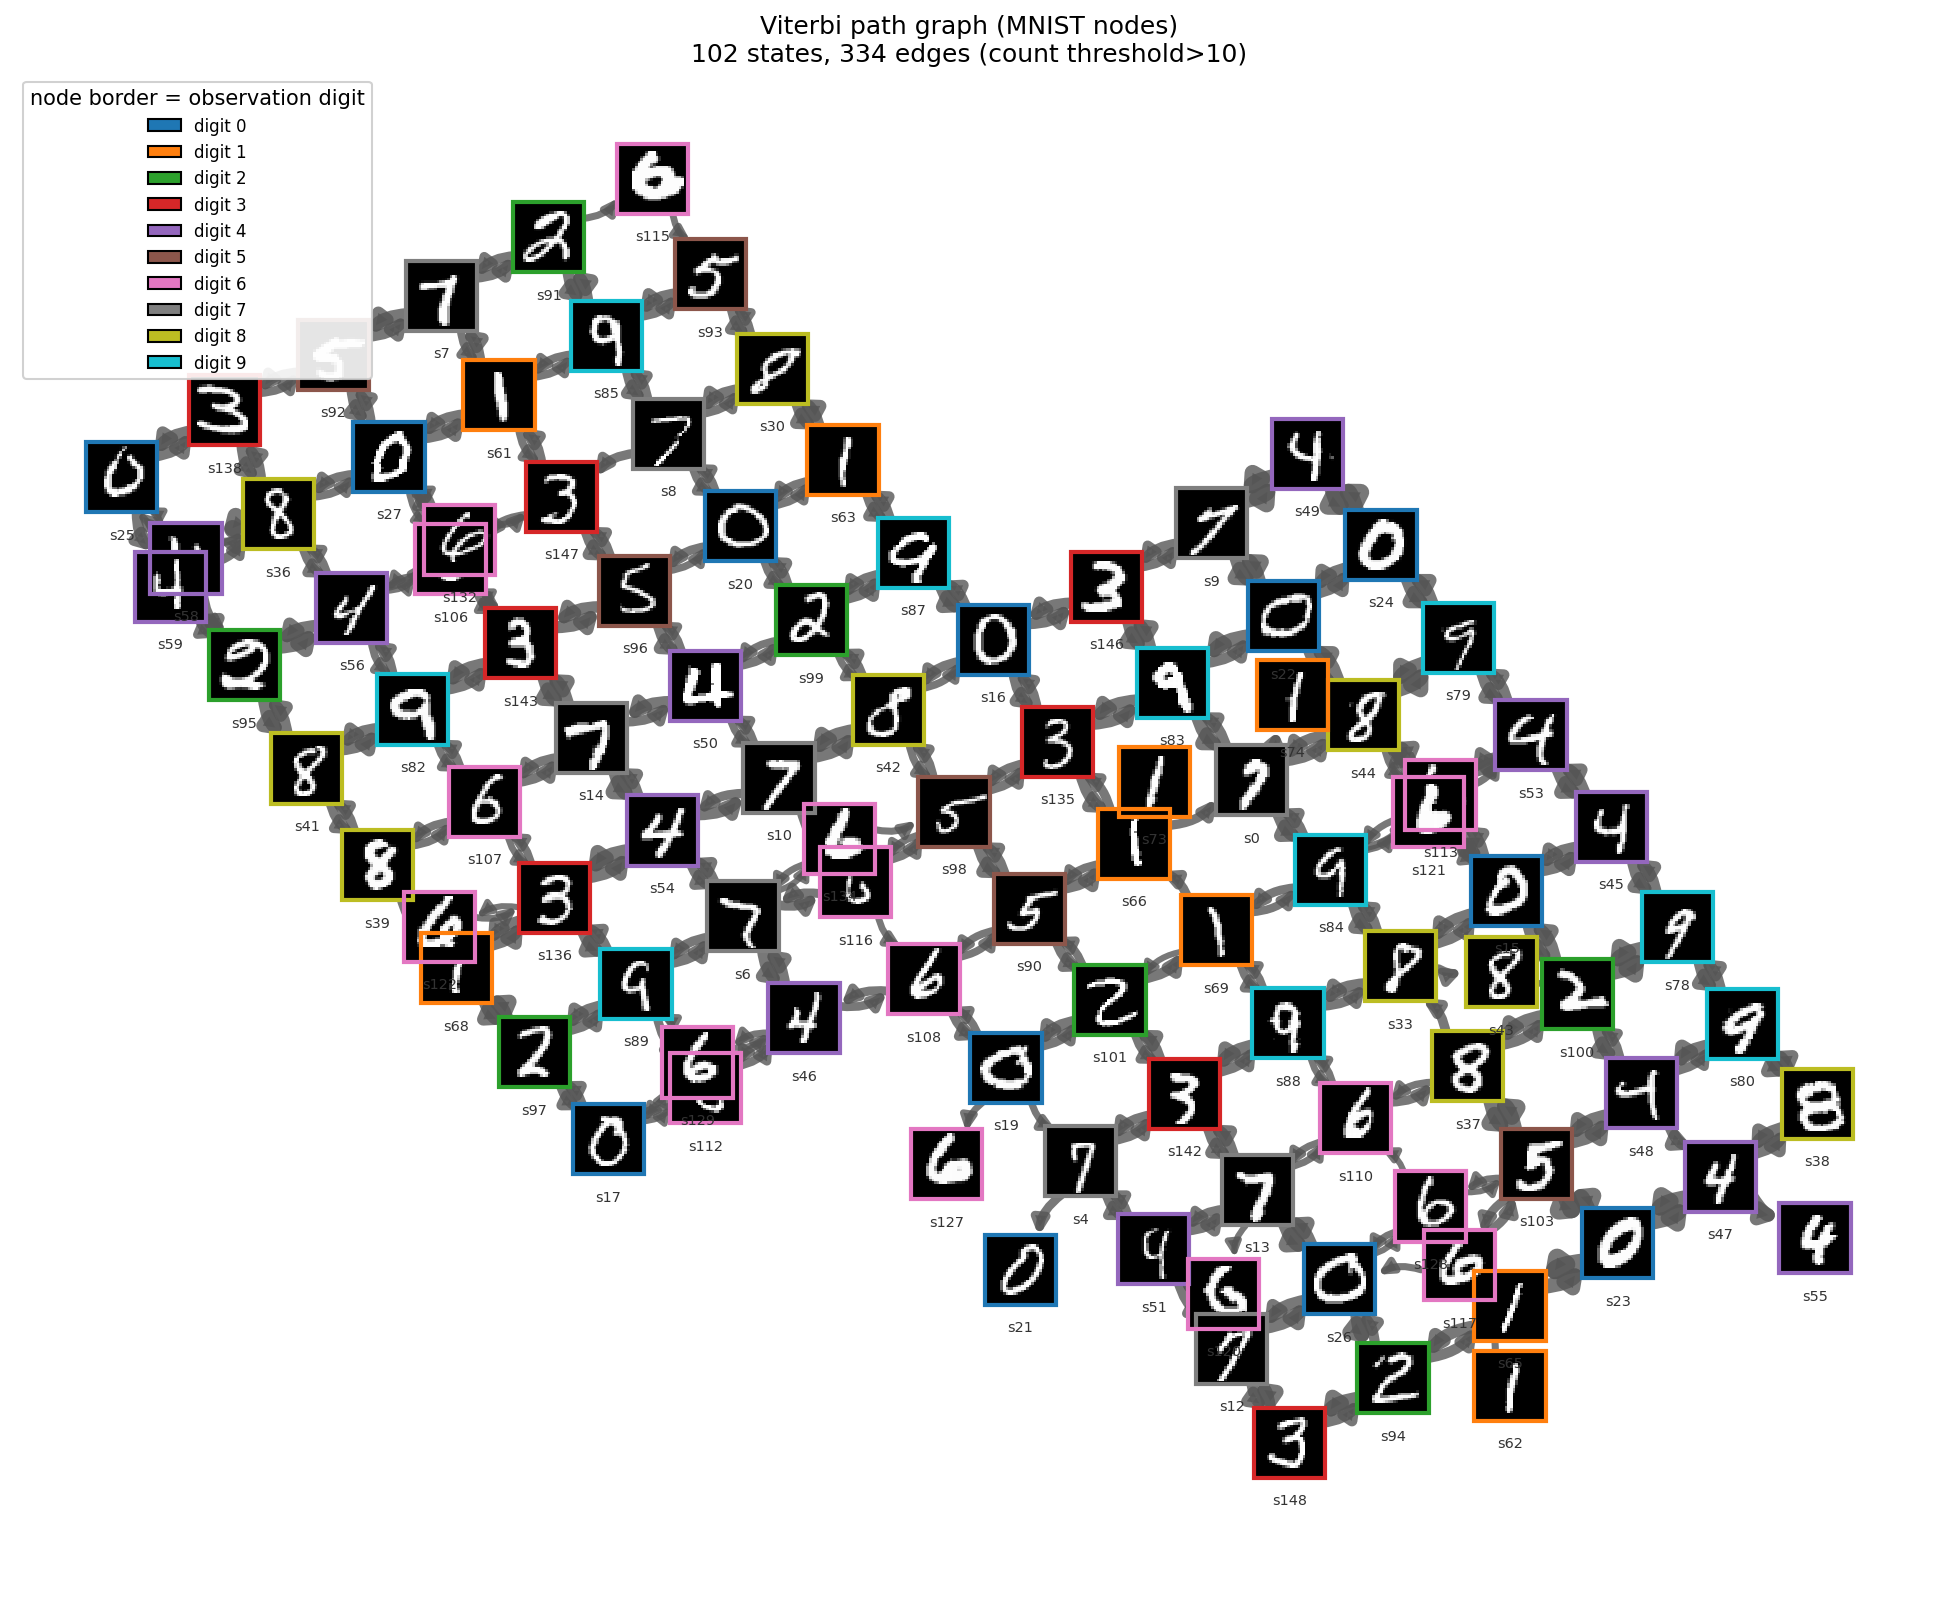

In [13]:
# WARNING: trains end-to-end -- about an hour on CPU. Not executed by default.
# Reproduces the `two_rooms` run.
import os
from models.vqvae_cscg import VQVAEGradientHMM
from environments.mnist_gridworld import example_grid_two_rooms
from examples.visualization import plot_clone_purity, render_viterbi_graph

# 1. Roll out episodes on the environment.
env = MNISTGridWorld(example_grid_two_rooms(), x_tr, y_tr, seed=0)
img_eps, act_eps, pos_eps, dig_eps = [], [], [], []
for _ in range(10):
    im, ac, po, di = env.rollout(steps=10000)
    img_eps.append(im); act_eps.append(ac); pos_eps.append(po); dig_eps.append(di)
train_images = np.concatenate(img_eps, axis=0)
train_labels = np.concatenate(dig_eps, axis=0)
print(f"collected {train_images.shape[0]} images over {len(img_eps)} episodes")

# 2. Build the VQ-VAE + cloned-HMM with the published hyperparameters.
model = VQVAEGradientHMM(
    image_shape=env.image_shape,
    codebook_size=10, num_clones=20,
    num_actions=env.num_actions, seed=0,
)

# 3. Phase 2 joint training + pure-HMM finalization.
history = model.fit_joint_pipeline(
    images=train_images,
    image_sequences=img_eps, action_sequences=act_eps,
    image_labels=train_labels, vqvae_supervision_weight=0.1,
    observation_clone_counts=[15, 15, 15, 15, 15, 15, 15, 15, 15, 15],
    joint_iters=2000,
    hmm_lr_multiplier=100,
    freeze_vqvae_during_joint=True,
    finalize_hmm_iters=1000,
    finalize_hmm_transition_entropy=0.001,
    seed=0, verbose=1,
)
nll = history.hmm_loss_history
print(f"\nVQ-VAE perplexity : {history.perplexity:.2f}  "
      f"({history.used_tokens} active tokens)")
print(f"joint HMM NLL     : {nll[0]:.1f} -> {nll[-1]:.1f}")
if history.finalize_history:
    print(f"finalize HMM NLL  : {history.finalize_history[0]:.1f} -> "
          f"{history.finalize_history[-1]:.1f}")

# 4. Visualizations: clone purity + Viterbi-path graph (MNIST-image nodes).
out = "_repro_two_rooms"
os.makedirs(out, exist_ok=True)
plot_clone_purity(model, img_eps[0], act_eps[0], pos_eps[0],
                  f"{out}/clone_purity.png")
render_viterbi_graph(model, img_eps[0], act_eps[0], dig_eps[0],
                     f"{out}/viterbi_graph.png", count_threshold=20,
                     title="Viterbi path graph (MNIST nodes) - two_rooms")
show_image(f"{out}/clone_purity.png", width=560)
show_image(f"{out}/viterbi_graph.png", width=560)